## Testing the Gadget for the $^{20}\text{O}$ in the Quasiparticle Picture

### Imports

In [49]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

### Load the coupling of the Quasiparticle Hamiltonian

We upload the $g^{(1)}_{AB}$ couplings from the numpy dictionary, we also fix the number of Qubit for the system that we are considering. Since the $^{6}\text{Be}$ involves only one active quasiparticle proton, we don't need any two-body interaction

In [53]:
import pickle

with open("data/doci_couplings_be2.pkl", "rb") as f:
    g, v, eps, E_core, meta = pickle.load(f)

n_qubits = 6

g_onebody = g
g_twobody = v

print(g_twobody)
diagonal_terms = eps
energy_shift = E_core
print(diagonal_terms)

g_matrix = np.zeros((n_qubits, n_qubits))
for a in range(n_qubits):
    for b in range(a + 1, n_qubits):
        g_matrix[a, b] = g_onebody[(a, b)]
        g_matrix[b, a] = g_onebody[(a, b)]
# get the computational basis of the space
print(g_matrix)
basis = computational_basis(n_qubits)

{(0, 1): np.float64(1.0029952848201749), (0, 2): np.float64(1.144841197672774), (0, 3): np.float64(1.1629788635519003), (0, 4): np.float64(1.1629788635519005), (0, 5): np.float64(1.1906263317877133), (1, 2): np.float64(1.048339849126519), (1, 3): np.float64(1.091193834026003), (1, 4): np.float64(1.0911938340260032), (1, 5): np.float64(1.101285838681184), (2, 3): np.float64(1.154686689553313), (2, 4): np.float64(1.1546866895533134), (2, 5): np.float64(1.1752179560833196), (3, 4): np.float64(1.155016498441354), (3, 5): np.float64(1.066886763283697), (4, 5): np.float64(1.1388475207517916)}
[-2.02109543 -1.66457897 -1.5856448  -1.59240743 -1.59240743 -1.416038  ]
[[0.         0.07908971 0.04979058 0.05142806 0.05142806 0.0335504 ]
 [0.07908971 0.         0.08514541 0.0359875  0.0359875  0.04853422]
 [0.04979058 0.08514541 0.         0.01463656 0.01463656 0.01504358]
 [0.05142806 0.0359875  0.01463656 0.         0.01247322 0.10198621]
 [0.05142806 0.0359875  0.01463656 0.01247322 0.        

#### Study the Quasiparticle Hamiltonian with the Hardcore Boson Basis

In [54]:
nparticles_a = 2
nparticles_b = 0

particle_conserved_basis = generate_particleconservation_basis(
    size_a=n_qubits, size_b=0, nparticles_a=nparticles_a, nparticles_b=nparticles_b
)

print(particle_conserved_basis)

# initialize the class in the number sector of the quasiparticle space (see NSMFermion library)
HBB = HardcoreBosonsBasis(basis=particle_conserved_basis)
quasiparticle_hamiltonian_particle_conserved = 0.0
for key, value in g_onebody.items():
    idx_a, idx_b = key
    if idx_a != idx_b:
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_a, idx_b
        )
        quasiparticle_hamiltonian_particle_conserved += value * HBB.adag_a_matrix(
            idx_b, idx_a
        )

for idx_a in range(n_qubits):
    quasiparticle_hamiltonian_particle_conserved += diagonal_terms[
        idx_a
    ] * HBB.adag_a_matrix(idx_a, idx_a)

for key, value in g_twobody.items():
    idx_a, idx_b = key
    print(idx_a, idx_b, value)
    quasiparticle_hamiltonian_particle_conserved += (
        0.5 * value * HBB.adag_adag_a_a_matrix(idx_a, idx_b, idx_a, idx_b)
    )
    quasiparticle_hamiltonian_particle_conserved += (
        0.5 * value * HBB.adag_adag_a_a_matrix(idx_b, idx_a, idx_b, idx_a)
    )
print(quasiparticle_hamiltonian_particle_conserved)
value, eigenstates_particle_conserved = np.linalg.eigh(
    quasiparticle_hamiltonian_particle_conserved.todense()
)

max_eigval_idx = np.argmax(value)
print(max_eigval_idx)

print(value + energy_shift)

[[1 1 0 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 1 0 0]
 [1 0 0 0 1 0]
 [1 0 0 0 0 1]
 [0 1 1 0 0 0]
 [0 1 0 1 0 0]
 [0 1 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 1 0 0]
 [0 0 1 0 1 0]
 [0 0 1 0 0 1]
 [0 0 0 1 1 0]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]]
0 1 1.0029952848201749
0 2 1.144841197672774
0 3 1.1629788635519003
0 4 1.1629788635519005
0 5 1.1906263317877133
1 2 1.048339849126519
1 3 1.091193834026003
1 4 1.0911938340260032
1 5 1.101285838681184
2 3 1.154686689553313
2 4 1.1546866895533134
2 5 1.1752179560833196
3 4 1.155016498441354
3 5 1.066886763283697
4 5 1.1388475207517916
<List of Lists sparse matrix of dtype 'float64'
	with 135 stored elements and shape (15, 15)>
  Coords	Values
  (0, 0)	-2.6826791127431173
  (0, 1)	0.08514540633333909
  (0, 2)	0.03598750460241827
  (0, 3)	0.035987504602418285
  (0, 4)	0.048534224845623565
  (0, 5)	0.049790580524014943
  (0, 6)	0.051428056185414385
  (0, 7)	0.051428056185414406
  (0, 8)	0.03355039713034268
  (1, 0)	0.08514540633333909
  (1, 1)	-2.461899033024664
  (

In [55]:
print(basis)

[[0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 0 0 0 1 1]
 [0 0 0 1 0 0]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]
 [0 0 0 1 1 1]
 [0 0 1 0 0 0]
 [0 0 1 0 0 1]
 [0 0 1 0 1 0]
 [0 0 1 0 1 1]
 [0 0 1 1 0 0]
 [0 0 1 1 0 1]
 [0 0 1 1 1 0]
 [0 0 1 1 1 1]
 [0 1 0 0 0 0]
 [0 1 0 0 0 1]
 [0 1 0 0 1 0]
 [0 1 0 0 1 1]
 [0 1 0 1 0 0]
 [0 1 0 1 0 1]
 [0 1 0 1 1 0]
 [0 1 0 1 1 1]
 [0 1 1 0 0 0]
 [0 1 1 0 0 1]
 [0 1 1 0 1 0]
 [0 1 1 0 1 1]
 [0 1 1 1 0 0]
 [0 1 1 1 0 1]
 [0 1 1 1 1 0]
 [0 1 1 1 1 1]
 [1 0 0 0 0 0]
 [1 0 0 0 0 1]
 [1 0 0 0 1 0]
 [1 0 0 0 1 1]
 [1 0 0 1 0 0]
 [1 0 0 1 0 1]
 [1 0 0 1 1 0]
 [1 0 0 1 1 1]
 [1 0 1 0 0 0]
 [1 0 1 0 0 1]
 [1 0 1 0 1 0]
 [1 0 1 0 1 1]
 [1 0 1 1 0 0]
 [1 0 1 1 0 1]
 [1 0 1 1 1 0]
 [1 0 1 1 1 1]
 [1 1 0 0 0 0]
 [1 1 0 0 0 1]
 [1 1 0 0 1 0]
 [1 1 0 0 1 1]
 [1 1 0 1 0 0]
 [1 1 0 1 0 1]
 [1 1 0 1 1 0]
 [1 1 0 1 1 1]
 [1 1 1 0 0 0]
 [1 1 1 0 0 1]
 [1 1 1 0 1 0]
 [1 1 1 0 1 1]
 [1 1 1 1 0 0]
 [1 1 1 1 0 1]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


#### Write the NSM Quasiparticle Hamiltonian

In [56]:
hamiltonian_xy = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_z += SpinOperator(
            [("qz", i, "qz", j)], coupling=[g_twobody[(i, j)]], size=n_qubits, verbose=1
        ).qutip_op

for i in range(n_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_terms[i]], size=n_qubits, verbose=1
    ).qutip_op

nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [57]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [58]:
print(eigenvalues_nsm + energy_shift, print(eigenstates_nsm[0].shape))

(64, 1)
[-28.74567876 -28.53765984 -28.50534058 -28.48048936 -28.26263468
 -28.2409594  -28.22228507 -28.21242613 -28.11383061 -28.10803346
 -28.10383906 -28.07590703 -28.06425345 -28.03197898 -28.00162592
 -27.98507272 -27.92101709 -27.83144374 -27.82557034 -27.81955626
 -27.80064984 -27.77710184 -27.74090013 -27.68998888 -27.65486708
 -27.65246929 -27.61908723 -27.58947654 -27.57756891 -27.54721871
 -27.54249381 -27.53767074 -27.48950784 -27.4388775  -27.34715772
 -27.34714975 -27.32333626 -27.29775107 -27.20745878 -27.14380419
 -26.99174805 -26.32326406 -26.29203998 -26.28800212 -26.12114513
 -26.02291291 -26.01609789 -26.01172489 -25.95240738 -25.8051237
 -25.76839386 -25.74328421 -25.65012048 -25.61080706 -25.57686838
 -25.4854596  -25.26097921 -23.34974848 -23.16445012 -23.15598792
 -23.05711148 -22.78040984 -22.58263578 -19.04649395] None


/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)
/home/ecosta/miniconda3/envs/nsm_gadget_env/lib/python3.11/site-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


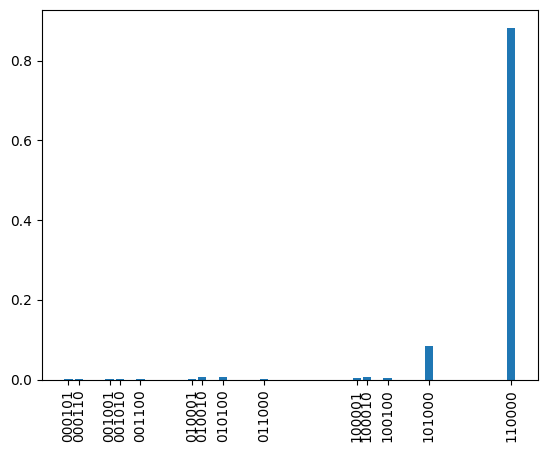

In [59]:
psi = eigenstates_nsm[0].full().flatten()
selected_bitstrings = np.arange(2**n_qubits)[np.abs(psi) > 10**-2]
selected_probs = (psi * np.conj(psi))[np.abs(psi) > 10**-2]
plt.bar(selected_bitstrings, selected_probs)
plt.xticks(
    selected_bitstrings,
    [f"{i:0{n_qubits}b}" for i in selected_bitstrings],
    rotation=90,
)
plt.show()

In [60]:
print(eigenvalues_nsm + energy_shift)
gs_idx = np.argmin(np.abs(eigenvalues_nsm - value[0]))
print(eigenstates_nsm[gs_idx].full())
print(gs_idx)

[-28.74567876 -28.53765984 -28.50534058 -28.48048936 -28.26263468
 -28.2409594  -28.22228507 -28.21242613 -28.11383061 -28.10803346
 -28.10383906 -28.07590703 -28.06425345 -28.03197898 -28.00162592
 -27.98507272 -27.92101709 -27.83144374 -27.82557034 -27.81955626
 -27.80064984 -27.77710184 -27.74090013 -27.68998888 -27.65486708
 -27.65246929 -27.61908723 -27.58947654 -27.57756891 -27.54721871
 -27.54249381 -27.53767074 -27.48950784 -27.4388775  -27.34715772
 -27.34714975 -27.32333626 -27.29775107 -27.20745878 -27.14380419
 -26.99174805 -26.32326406 -26.29203998 -26.28800212 -26.12114513
 -26.02291291 -26.01609789 -26.01172489 -25.95240738 -25.8051237
 -25.76839386 -25.74328421 -25.65012048 -25.61080706 -25.57686838
 -25.4854596  -25.26097921 -23.34974848 -23.16445012 -23.15598792
 -23.05711148 -22.78040984 -22.58263578 -19.04649395]
[[ 0.00000000e+00+0.j]
 [ 1.28435758e-21+0.j]
 [-2.61655287e-18+0.j]
 [-9.52288132e-03+0.j]
 [-7.26246696e-19+0.j]
 [-1.10164500e-02+0.j]
 [-1.54700895e-02

Now, we get the spectrum of this Hamiltonian

### Puzzle of the Effective interaction

Following our notes on the gadget, we need to verify if we can reproduce the interaction by using the transverse field per site $d_i$. Since the relevant term in the effective Hamiltonian comes out as $H_{\text{int,eff}}=-\frac{1}{\gamma}\sum_{A \neq B} d_A d_B (X_A X_B +Y_A Y_B)$. We need to figure out if we can solve the condition $g_{AB}=-d_A d_B$. To do so, we treat it as an optimization problem. 

Optimal drive parameters: [0.25604277 0.28557215 0.17886289 0.20331619 0.13811076 0.21353169]
Optimized effective interaction matrix:
 [[ 0.          0.00597103  0.00399403 -0.00062958  0.01606579 -0.02112285]
 [ 0.00597103  0.          0.03406715 -0.02207394 -0.00345308 -0.01244448]
 [ 0.00399403  0.03406715  0.         -0.02172916 -0.01006633 -0.02314931]
 [-0.00062958 -0.02207394 -0.02172916  0.         -0.01560693  0.05857176]
 [ 0.01606579 -0.00345308 -0.01006633 -0.01560693  0.          0.00864606]
 [-0.02112285 -0.01244448 -0.02314931  0.05857176  0.00864606  0.        ]]


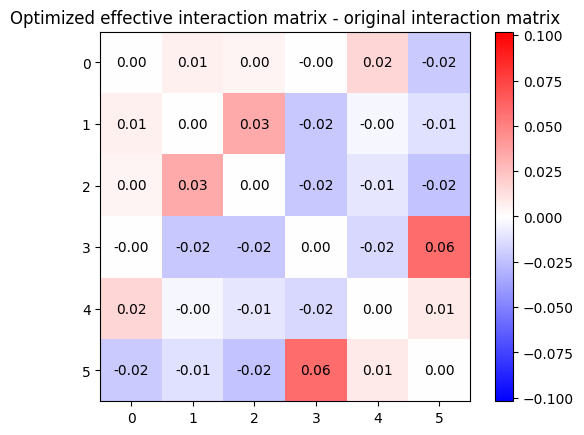

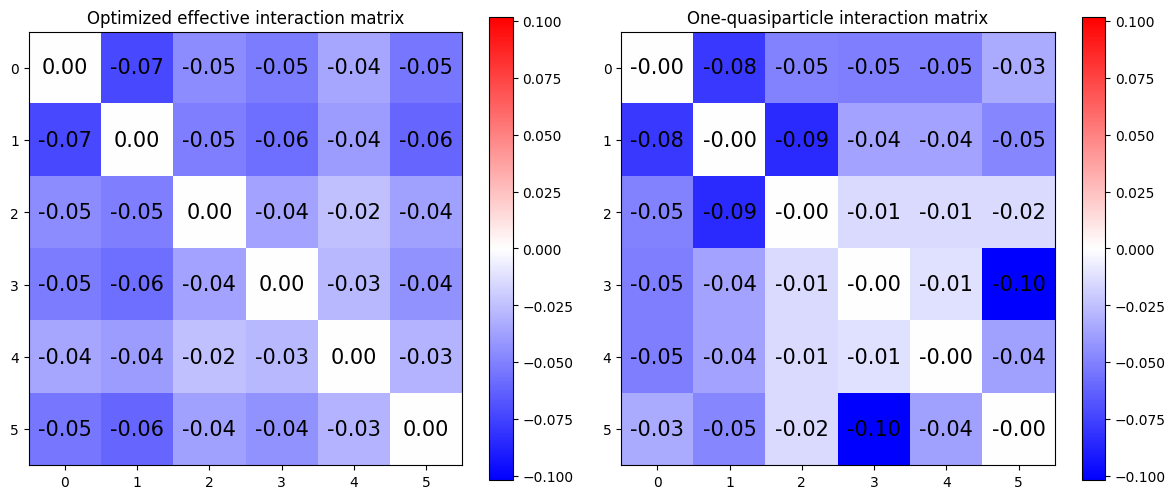

In [61]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(-g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) + g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) + g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(n_qubits):
    for j in range(n_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]+g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), -1 * g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(n_qubits):
        for j in range(n_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Write the Diagonal part of the Ising Hamiltonian

Now, we have to write the full ising Hamiltonian that describes the constrain subspace, where our effective Hamiltonian acts, and then see how the spectrum behaves

#### Define the hamiltonian $H_z$ out of the couplings and constrains

In [76]:
# get the total particle constrain
gamma = 300
ntot = 2
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = -1 * (diagonal_terms + 0.5 * (d_opt**2).sum()) / (gamma)
print(effective_longitudinal_field)

# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)],
            coupling=[2 * gamma - g_twobody[(i, j)] / gamma],
            size=n_qubits,
            verbose=1,
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

longitudinal_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

[0.0062618  0.00507341 0.0048103  0.00483284 0.00483284 0.00424494]


In [77]:
print(longitudinal_hamiltonian.diag())
print(basis)

[1.20000000e+03 3.00004245e+02 3.00004833e+02 5.28162931e-03
 3.00004833e+02 5.52149850e-03 5.81563082e-03 3.00002708e+02
 3.00004810e+02 5.13785241e-03 5.79418807e-03 3.00002326e+02
 5.79418807e-03 3.00002565e+02 3.00002928e+02 1.19999590e+03
 3.00005073e+02 5.64740670e-03 6.26894482e-03 3.00003047e+02
 6.26894482e-03 3.00003287e+02 3.00003614e+02 1.19999684e+03
 6.38924932e-03 3.00003046e+02 3.00003736e+02 1.19999660e+03
 3.00003736e+02 1.19999684e+03 1.19999723e+03 2.69998654e+03
 3.00006262e+02 6.53799326e-03 7.21804959e-03 3.00003698e+02
 7.21804959e-03 3.00003938e+02 3.00004324e+02 1.19999725e+03
 7.25596637e-03 3.00003615e+02 3.00004363e+02 1.19999693e+03
 3.00004363e+02 1.19999717e+03 1.19999762e+03 2.69998663e+03
 7.99189997e-03 3.00004597e+02 3.00005311e+02 1.19999812e+03
 3.00005311e+02 1.19999836e+03 1.19999878e+03 2.69998803e+03
 3.00005492e+02 1.19999818e+03 1.19999896e+03 2.69998785e+03
 1.19999896e+03 2.69998809e+03 2.69998858e+03 4.79997392e+03]
[[0 0 0 0 0 0]
 [0 0 0 

#### Plot a representation of the diagonal part of the Ising Hamiltonian

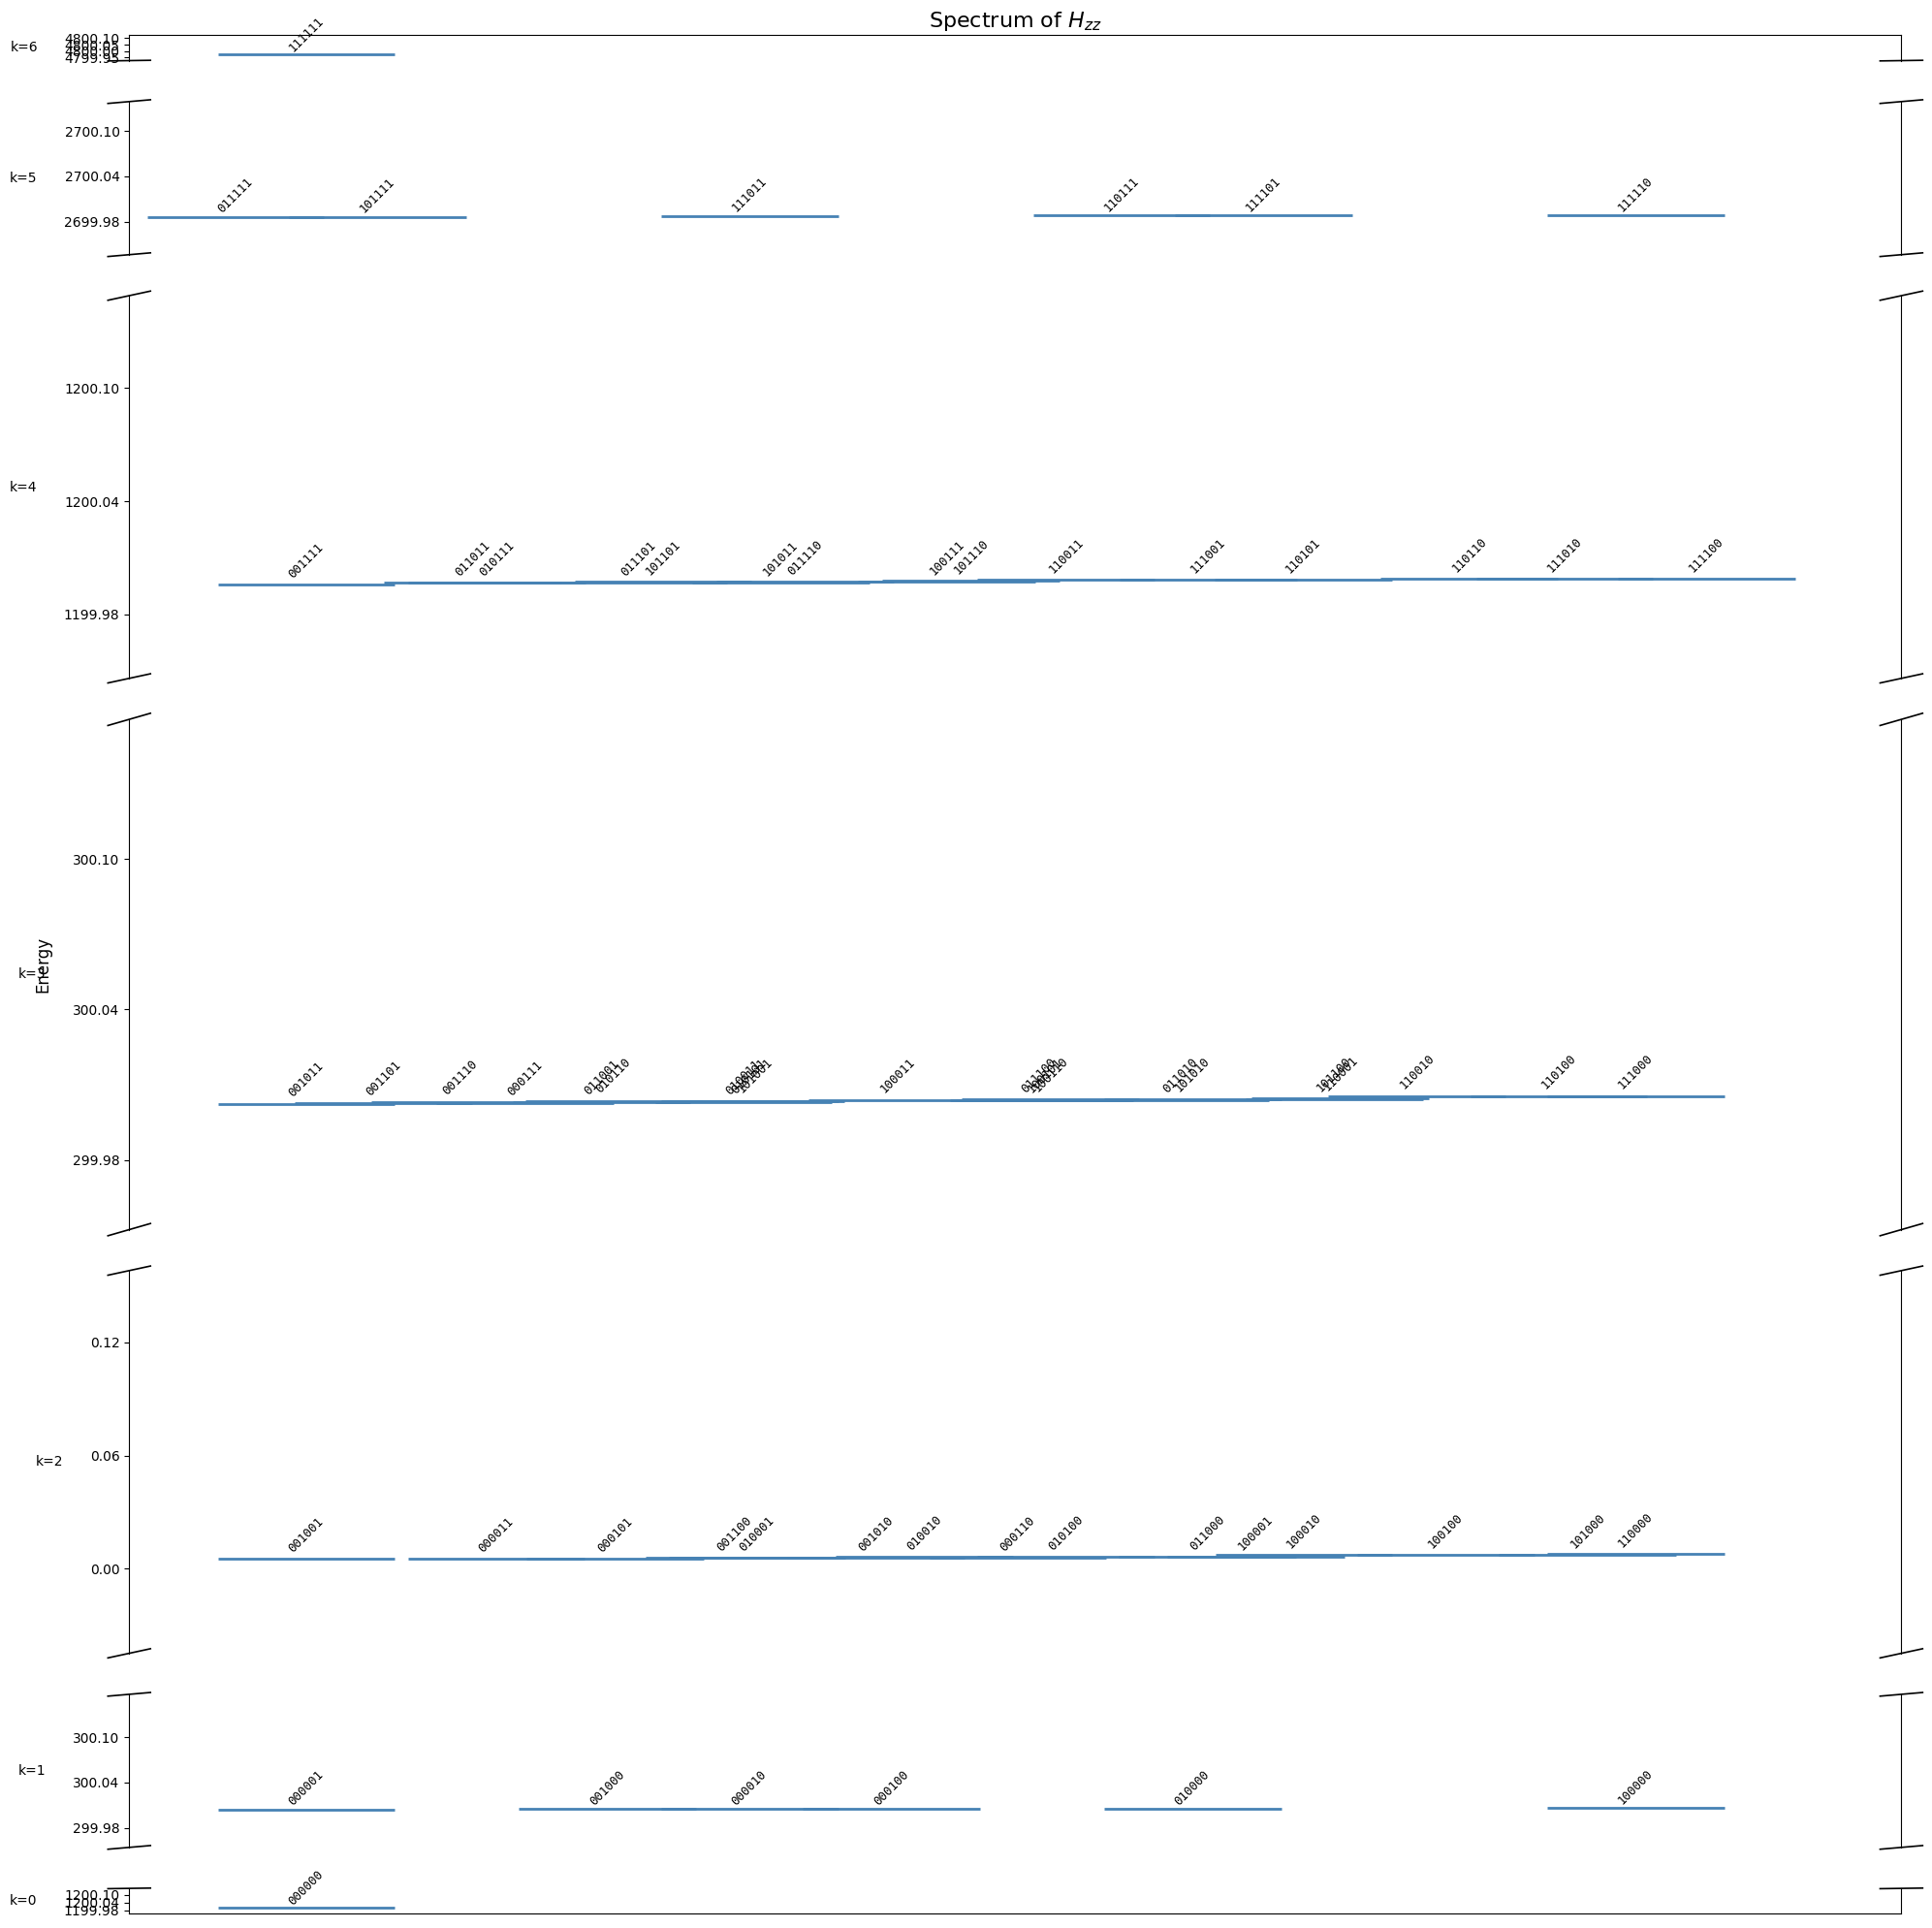

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

#### this should go to the utils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


def plot_spectrum(
    energies, basis, figsize=(14, 10), fontsize=9, linewidth=2.0, label_offset=0.02
):
    """
    Plot energy spectrum split by particle number (Hamming weight).
    Each panel corresponds to a fixed number of excitations.

    Parameters
    ----------
    energies : array, shape (N,)
    basis : array, shape (N, n_qubits)
    figsize : tuple
    fontsize : int
    linewidth : float
    label_offset : float
        Vertical offset of labels above lines, as fraction of span.
    """
    energies = np.real(np.array(energies))
    labels = ["".join(map(str, row)) for row in basis]

    # --- split by Hamming weight ---
    hamming = basis.sum(axis=1)
    unique_sectors = np.sort(np.unique(hamming))

    splits = []
    sector_labels = []
    for k in unique_sectors:
        idx = np.where(hamming == k)[0]
        idx = idx[np.argsort(energies[idx])]
        splits.append(idx)
        sector_labels.append(k)

    # highest particle number at top
    splits = splits[::-1]
    sector_labels = sector_labels[::-1]

    n_panels = len(splits)
    heights = [max(len(s), 1) for s in splits]

    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=figsize,
        gridspec_kw={"height_ratios": heights},
        squeeze=False,
    )
    axes = axes.flatten()

    for ax, group, k in zip(axes, splits, sector_labels):
        es = energies[group]
        ls = [labels[i] for i in group]
        n = len(es)

        span = es.max() - es.min()
        degen_tol = max(span * 0.05, 1e-6)

        # cluster nearly-degenerate levels into columns
        columns = []
        for i, e in enumerate(es):
            placed = False
            for col in columns:
                if abs(e - es[col[0]]) < degen_tol:
                    col.append(i)
                    placed = True
                    break
            if not placed:
                columns.append([i])

        n_cols = len(columns)
        col_x = np.linspace(0.1, 0.85, max(n_cols, 1))

        for col_idx, col in enumerate(columns):
            cx = col_x[col_idx]
            n_in_col = len(col)
            if n_in_col > 1:
                xs = np.linspace(
                    cx - 0.04 * (n_in_col - 1), cx + 0.04 * (n_in_col - 1), n_in_col
                )
            else:
                xs = [cx]

            for x, idx in zip(xs, col):
                e = es[idx]
                label = ls[idx]
                ax.hlines(e, x - 0.05, x + 0.05, linewidth=linewidth, color="steelblue")
                ax.text(
                    x,
                    e + label_offset * max(span, 0.1),
                    label,
                    va="bottom",
                    ha="center",
                    fontsize=fontsize,
                    fontfamily="monospace",
                    rotation=45,
                )

        margin = max(span * 0.4, 0.05)
        ax.set_ylim(es.min() - margin, es.max() + margin * 3.0)
        ax.set_xlim(0, 1.0)
        ax.set_xticks([])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

        formatter = ScalarFormatter(useOffset=False)
        formatter.set_scientific(False)
        ax.yaxis.set_major_formatter(formatter)

        # label sector on right
        ax.set_ylabel(f"k={k}", fontsize=10, rotation=0, labelpad=30, va="center")

    # --- broken axis styling ---
    for ax in axes[:-1]:
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(bottom=False)
    for ax in axes[1:]:
        ax.spines["top"].set_visible(False)

    # break marks
    d = 0.012
    for ax_top, ax_bot in zip(axes[:-1], axes[1:]):
        for ax, y in [(ax_top, 0), (ax_bot, 1)]:
            kw = dict(color="k", clip_on=False, linewidth=1.2, transform=ax.transAxes)
            ax.plot((-d, +d), (y - d, y + d), **kw)
            ax.plot((1 - d, 1 + d), (y - d, y + d), **kw)

    axes[0].set_title(r"Spectrum of $H_{zz}$", fontsize=16)
    fig.text(0.02, 0.5, "Energy", va="center", rotation="vertical", fontsize=12)

    plt.tight_layout()
    plt.show()


plot_spectrum(longitudinal_hamiltonian.diag(), basis, figsize=(20, 20))

### Part of the second step is to introduce the transverse field term

In [79]:
# the transverse field
transverse_hamiltonian = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    transverse_hamiltonian += SpinOperator(
        [("x", i)], coupling=[-d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=1
    ).qutip_op

#### Compute the spectrum of the full Hamiltonian

Once that we compute the spectrum, we expect that our ground state lies in the subspace near the $E_0=0$ region, Let's see what we get

In [80]:
total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian
eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
    total_hamiltonian
).eigenstates()

#### Check the structure of the effective Hamiltonian to control the longitudinal couplings $g_{AA}$

In [81]:
print(eigenvalues_total_hamiltonian[:45] * gamma - energy_shift)
# highest eigenvalue, in the quantum annealing does not change
print(
    fidelity(
        eigenstates_total_hamiltonian[max_eigval_idx],
        eigenstates_nsm[gs_idx],
    )
)

[2.72757709e+01 2.74256995e+01 2.74894221e+01 2.75328284e+01
 2.75965259e+01 2.76337094e+01 2.76535610e+01 2.77595744e+01
 2.77995497e+01 2.78230268e+01 2.78307526e+01 2.80250230e+01
 2.80873191e+01 2.81038447e+01 2.83089814e+01 9.00267231e+04
 9.00268073e+04 9.00268425e+04 9.00269047e+04 9.00269674e+04
 9.00269745e+04 9.00270470e+04 9.00271316e+04 9.00271345e+04
 9.00271523e+04 9.00271688e+04 9.00271777e+04 9.00272282e+04
 9.00273348e+04 9.00273433e+04 9.00273490e+04 9.00273772e+04
 9.00275049e+04 9.00275511e+04 9.00275646e+04 9.00276098e+04
 9.00276273e+04 9.00277281e+04 9.00277483e+04 9.00277944e+04
 9.00280600e+04 3.60024795e+05 3.60025014e+05 3.60025088e+05
 3.60025092e+05]
0.9825553827555178


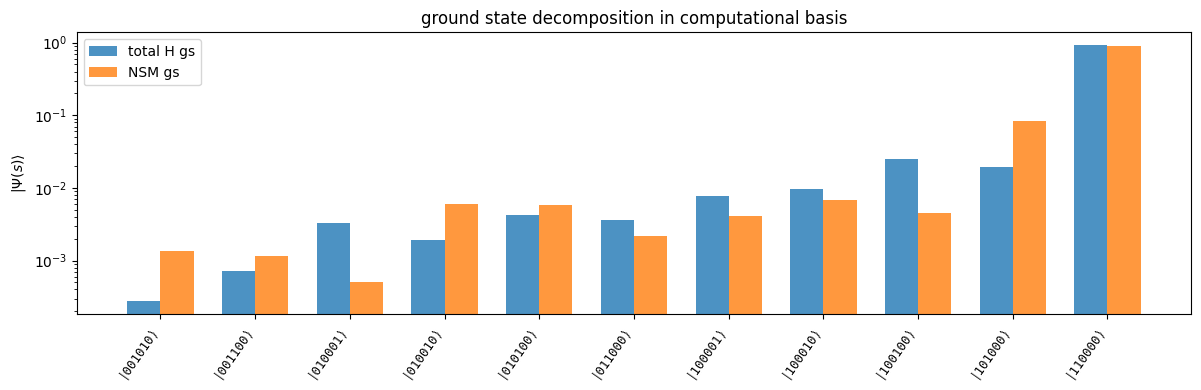

In [82]:
import matplotlib.pyplot as plt
import numpy as np


def plot_state_comparison(
    state1, state2, basis, label1="total H gs", label2="NSM gs", threshold=1e-3
):
    amps1 = state1.full().flatten()
    amps2 = state2.full().flatten()

    probs1 = np.abs(amps1) ** 2
    probs2 = np.abs(amps2) ** 2

    # filter: keep basis states where either state has weight above threshold
    mask = (probs1 > threshold) | (probs2 > threshold)
    bit_labels = ["|" + "".join(str(b) for b in bits) + "⟩" for bits in basis[mask]]
    p1 = probs1[mask]
    p2 = probs2[mask]

    x = np.arange(len(bit_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - width / 2, p1, width, label=label1, alpha=0.8)
    ax.bar(x + width / 2, p2, width, label=label2, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        bit_labels, rotation=55, ha="right", fontsize=9, fontfamily="monospace"
    )
    ax.set_ylabel(r"$|\Psi(s)\rangle $")
    ax.legend()
    ax.set_title("ground state decomposition in computational basis")
    plt.tight_layout()
    plt.semilogy()
    plt.show()


plot_state_comparison(
    eigenstates_total_hamiltonian[max_eigval_idx],
    eigenstates_nsm[gs_idx],
    basis,
)

#### Adiabatic State Preparation

We divide the initialization of the total hamiltonian, since the driver is just the 0-th component of the Z hamiltonian. We just need to tune the initialization of the other components

In [ ]:
# get the total particle constrain
gamma = 8
ntot = 1
# we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

total_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)
# the transverse field is part of the variable hamiltonian
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    total_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
    ).qutip_op

Then the driver Hamiltonian

In [ ]:
# get the total particle constrain
ntot = 1
# we define the effective longitudianl field that contributes to the driver hamiltonian hamiltonian of Be 6
external_field = np.zeros(diagonal_elements.shape[0])
external_field[0] = diagonal_elements[0]
print(external_field)

effective_longitudinal_field = (external_field) / (gamma)


# lets start with the Z_A Z_B of the constrain
hamiltonian_zz = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_zz += SpinOperator(
            [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
        ).qutip_op

# then the linear terms
hamiltonian_z = 0.0
for i in range(n_qubits):
    # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
    hamiltonian_z += SpinOperator(
        [("qz", i)],
        coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
        size=n_qubits,
        verbose=1,
    ).qutip_op

# finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

driver_hamiltonian = (
    hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
)

print(np.argsort(driver_hamiltonian.full().diagonal()))
idx_init = np.argsort(driver_hamiltonian.full().diagonal())[0]

[-9.3151  0.      0.      0.      0.      0.    ]
[32  1  2  4  8 16 34 36 40 48 33 24 20 18 17  0 12 10  9  6  5  3 52 41
 49 38 37 50 56 35 44 42 25  7 28 26 11 22 13 21 19 14 60 46 45 58 53 39
 57 54 43 51 30 29 27 23 15 62 55 59 47 61 31 63]


Then we get the state preparation, initializing the state and evolving the interpolate hamiltonian

Time evolution

In [ ]:
#### Initialize the state and convert the hamiltonians
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
print(total_hamiltonian_sparse)
# initialize the state
psi = np.zeros(basis.shape[0])
print(basis[idx_init])
psi[idx_init] = 1.0

print(psi.conj().T @ driver_hamiltonian_sparse @ psi)

#### start the time evolution

nlevels = 3
tau = 50
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)
for i, t in enumerate(time):
    hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
        t / tau
    ) * total_hamiltonian_sparse
    psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)
    eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which="SA")
    idx = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    spectrum[i] = eigenvalues
    energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
print("final energy=", psi.conj().dot(total_hamiltonian_sparse.dot(psi)))

<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 448 stored elements and shape (64, 64)>
  Coords	Values
  (0, 0)	(8+0j)
  (0, 1)	(-0.8025815474625145+0j)
  (0, 2)	(0.7814154710541742+0j)
  (0, 4)	(0.561568352924687+0j)
  (0, 8)	(0.6799047505495625+0j)
  (0, 16)	(-0.7250345008592279+0j)
  (0, 32)	(0.6400237137047129+0j)
  (1, 0)	(-0.8025815474625145+0j)
  (1, 1)	(0.774097768137139+0j)
  (1, 3)	(0.7814154710541742+0j)
  (1, 5)	(0.561568352924687+0j)
  (1, 9)	(0.6799047505495625+0j)
  (1, 17)	(-0.7250345008592279+0j)
  (1, 33)	(0.6400237137047129+0j)
  (2, 0)	(0.7814154710541742+0j)
  (2, 2)	(0.774097768137139+0j)
  (2, 3)	(-0.8025815474625145+0j)
  (2, 6)	(0.561568352924687+0j)
  (2, 10)	(0.6799047505495625+0j)
  (2, 18)	(-0.7250345008592279+0j)
  (2, 34)	(0.6400237137047129+0j)
  (3, 1)	(0.7814154710541742+0j)
  (3, 2)	(-0.8025815474625145+0j)
  (3, 3)	(9.548195536274278+0j)
  (3, 7)	(0.561568352924687+0j)
  :	:
  (60, 56)	(0.561568352924687+0j)
  (60, 60)	(69.055253572

/tmp/ipykernel_1366/1945053173.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t_sparse.dot( psi))


final energy= (-1.4298953172638076+0j)


Results of the QA state preparation

fidelity= 0.9462165899024976 -0.06045945573827529


/tmp/ipykernel_1366/995074342.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20)


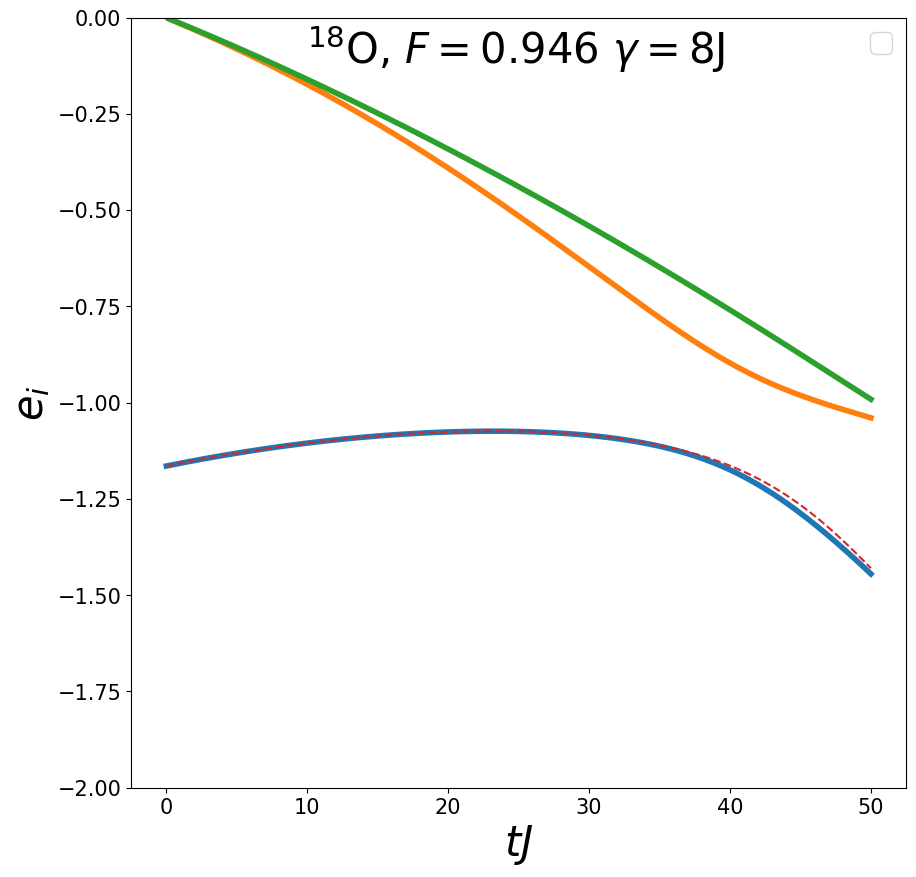

-11.43916253811046


In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(time, spectrum, linewidth=4)
plt.plot(time, energy, linestyle="--")
psi_qutip = array_to_qutip(psi, n_qubits)
f_value = fidelity(psi_qutip, eigenstates_total_hamiltonian[0])
print(
    "fidelity=",
    fidelity(psi_qutip, eigenstates_total_hamiltonian[0]),
    eigenvalues_total_hamiltonian[0],
)
plt.text(
    x=10,
    y=-0.12,
    s=r"$^{18}\text{O}$, $F=$" + f"{f_value:.3f} " + r"$\gamma=$" + f"{gamma:.0f}J",
    fontsize=30,
)
plt.xlabel(r"$tJ$", fontsize=30)
plt.ylabel(r"$e_i$", fontsize=30)
plt.legend(fontsize=20)
plt.tick_params(which="major", labelsize=15)
plt.ylim([-2, 0])
plt.show()

print(energy[-1] * gamma)

#### Robstness of the Gadget vs $\gamma$

We study the robustness of the Gadget Hamiltonian tuning the $\gamma$ parameter, to check if we can reduce it to comparable values

In [ ]:
from qutip import fidelity

gammas = np.linspace(1, 200, 40)
energy_error = []
fidelities = []
for gamma in gammas:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op

    eigenvalues_total_hamiltonian, eigenstates_total_hamiltonian = (
        total_hamiltonian.eigenstates()
    )
    print(
        eigenvalues_total_hamiltonian[0] * gamma,
        value[0],
    )
    energy_error.append(
        np.abs(eigenvalues_total_hamiltonian[0] * gamma - value[0]) / np.abs(value[0])
    )
    print(
        "fidelities=",
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx]),
        "\n",
    )
    fidelities.append(
        qt.fidelity(eigenstates_total_hamiltonian[0], eigenstates_nsm[gs_idx])
    )

-15.856290275229314 -11.931788251561521
fidelities= 0.03764381452599968 

-11.318216244816316 -11.931788251561521
fidelities= 0.9328154022650927 

-11.78147634559132 -11.931788251561521
fidelities= 0.9742972786419934 

-11.933783525753647 -11.931788251561521
fidelities= 0.9860154369174743 

-11.997697391344374 -11.931788251561521
fidelities= 0.9908238568409701 

-12.029895071100976 -11.931788251561521
fidelities= 0.9932296059601722 

-12.04824335138269 -11.931788251561521
fidelities= 0.9945965016644982 

-12.059648465790472 -11.931788251561521
fidelities= 0.9954448363501257 

-12.067206927300994 -11.931788251561521
fidelities= 0.9960065354352658 

-12.072468005109057 -11.931788251561521
fidelities= 0.9963972772983261 

-12.076274522679999 -11.931788251561521
fidelities= 0.9966798752905465 

-12.079116182850452 -11.931788251561521
fidelities= 0.9968907814028403 

-12.081293018035927 -11.931788251561521
fidelities= 0.9970523104678786 

-12.082997052969437 -11.931788251561521
fidelities= 

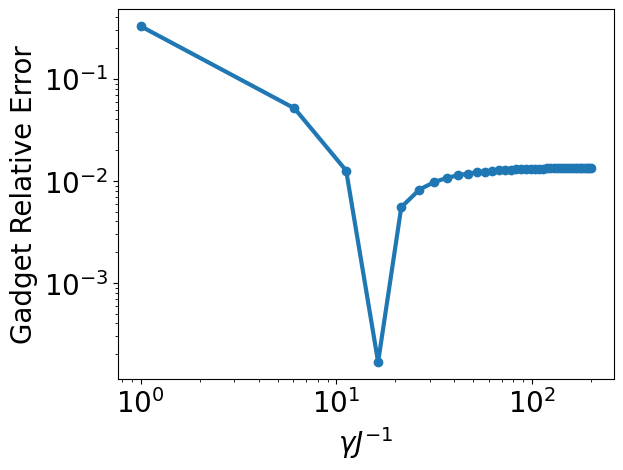

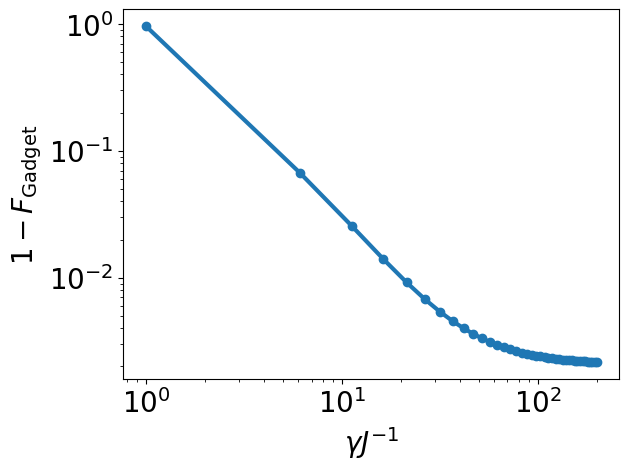

In [ ]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel("Gadget Relative Error", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$1-F_{\text{Gadget}}$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

#### What about the state preparation using QA then ??

In [ ]:
import scipy.sparse as sp
from scipy.sparse.linalg import expm_multiply

fidelities = []
energy_error = []
gammas = np.linspace(1, 50, 10)
for gamma in gammas:
    # get the total particle constrain
    ntot = 1
    # we define the effective longitudianl field that contributes to the NSM quasiparticle hamiltonian of Be 6
    effective_longitudinal_field = (diagonal_elements + 0.5 * (d_opt**2).sum()) / (
        gamma
    )

    # lets start with the Z_A Z_B of the constrain
    hamiltonian_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            hamiltonian_zz += SpinOperator(
                [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=1
            ).qutip_op

    # then the linear terms
    hamiltonian_z = 0.0
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        hamiltonian_z += SpinOperator(
            [("qz", i)],
            coupling=[effective_longitudinal_field[i] + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=1,
        ).qutip_op

    # finally add the identity such that the single quasiparticle ground state (without effective terms) centers in zero
    identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)

    total_hamiltonian = (
        hamiltonian_zz + hamiltonian_z + gamma * (ntot**2) * identity_qubit_space
    )
    # the transverse field is part of the variable hamiltonian
    for i in range(n_qubits):
        # we add \gamma (1-ntot) since it's the linear part of the particle number constrain
        total_hamiltonian += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / (np.sqrt(2))], size=n_qubits, verbose=1
        ).qutip_op
    #### Initialize the state and convert the hamiltonians

    total_hamiltonian_sparse = total_hamiltonian.data.as_scipy()
    driver_hamiltonian_sparse = driver_hamiltonian.data.as_scipy()
    # initialize the state
    psi = np.zeros(basis.shape[0])
    psi[idx_init] = 1.0

    #### start the time evolution

    nlevels = 3
    tau = 10 * gamma
    time_steps = int(10 * tau)
    time = np.linspace(0, tau, time_steps)
    delta_t = time[1] - time[0]
    spectrum = np.zeros((time_steps, nlevels))
    energy = np.zeros(time_steps)
    for i, t in enumerate(time):
        hamiltonian_t_sparse = (1 - t / tau) * driver_hamiltonian_sparse + (
            t / tau
        ) * total_hamiltonian_sparse
        psi = expm_multiply(-1j * delta_t * hamiltonian_t_sparse, psi)
        eigenvalues, eigenvectors = eigsh(hamiltonian_t_sparse, k=nlevels, which="SA")
        idx = np.argsort(eigenvalues)
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        spectrum[i] = eigenvalues
        energy[i] = psi.conj().dot(hamiltonian_t_sparse.dot(psi))
    psi_qutip = array_to_qutip(psi, n_qubits)
    energy_error.append(np.abs(energy[-1] * gamma - value[0]) / np.abs(value[0]))
    f_value = fidelity(psi_qutip, eigenstates_total_hamiltonian[0])
    fidelities.append(f_value)
    print(gamma)
    print("energy=", energy[-1] * gamma)
    print("fidelity=", fidelity(psi_qutip, eigenstates_total_hamiltonian[0]))

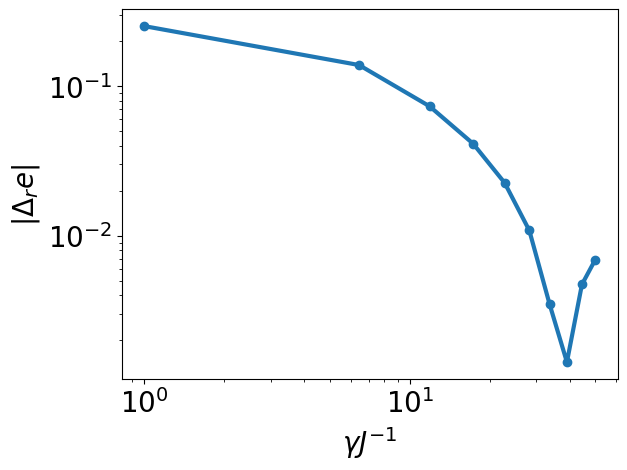

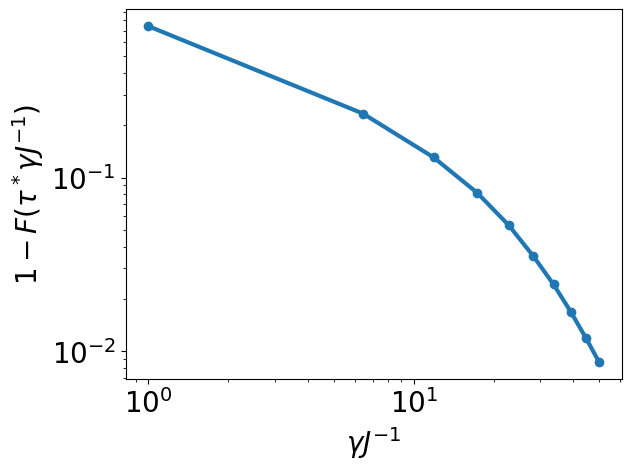

In [ ]:
plt.plot(gammas, energy_error, linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$|\Delta_r e|$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()

plt.plot(gammas, 1 - np.array(fidelities), linewidth=3, marker="o")
plt.xlabel(r"$\gamma J^{-1}$", fontsize=20)
plt.ylabel(r"$1-F(\tau^* \gamma J^{-1} )$", fontsize=20)
plt.tick_params(labelsize=20)
plt.loglog()
plt.show()